In [4]:
import pandas as pd
import matplotlib.pyplot as plt
#import japanize_matplotlib
import seaborn as sns
import numpy as np

# 日本語フォントの設定（環境に合わせて設定してください）
plt.rcParams["font.family"] = "Yu Gothic"   # Windows
#plt.rcParams['font.family'] = 'sans-serif' # Windowsなど
# plt.rcParams['font.family'] = 'AppleGothic' # Macの場合

# 1. データの読み込み
# 実際のファイル名やパスに合わせて変更してください
df = pd.read_parquet(
    "/Users/reiyamamoto/Documents/GitHub/DataScienceCompetition/parquet_data/1571_ja.parquet",
    engine="fastparquet"
)
# ここではダミーとしてdfが読み込まれていると仮定します

有効データ数: 11501


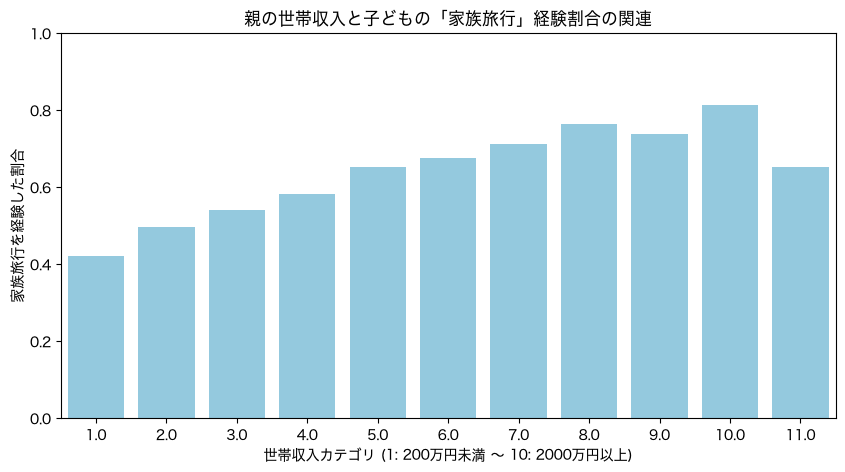

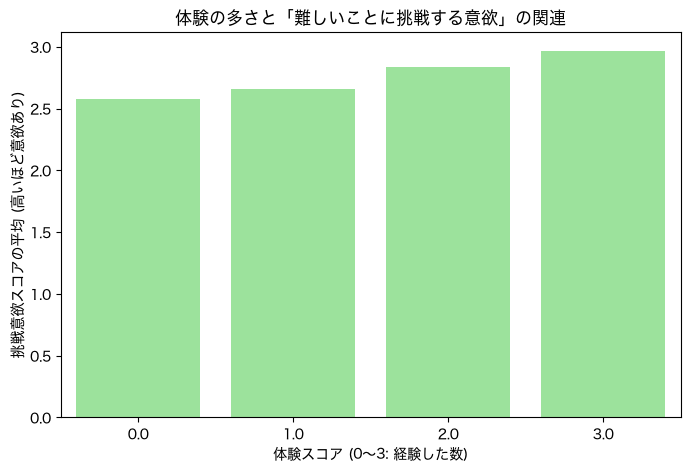

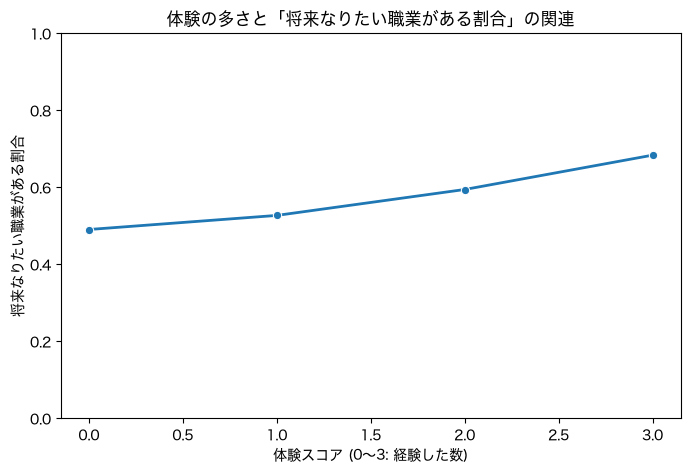

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mac用の日本語フォント設定（グラフの文字化け防止）
plt.rcParams['font.family'] = 'Hiragino Sans' # もしエラーが出る場合は 'AppleGothic' に変更してください

# 1. データの読み込み
df = pd.read_parquet(
    "/Users/reiyamamoto/Documents/GitHub/DataScienceCompetition/parquet_data/1571_ja.parquet",
    engine="fastparquet"
)

# 2. 実際のデータに合わせた日本語の列名に修正
columns_to_use = [
    'w1p_昨年の世帯収入', 
    'w1c_経験：家族で旅行をする', 
    'w1c_経験：自然の中で思いっきり遊ぶ', 
    'w1c_経験：美術館や博物館に行く', 
    'w1c_性格・特性：難しいことや新しいことにいつも挑戦したい', 
    'w1c_将来なりたい職業はあるか' 
]

# 分析用データフレームの作成
df_subset = df[columns_to_use].copy()

# 3. 欠損値の処理
# 7777, 8888, 9999 をまとめてNaN(欠損値)に置き換えて除外する
for col in columns_to_use:
    df_subset[col] = df_subset[col].replace([7777, 8888, 9999], np.nan)

df_subset = df_subset.dropna()
print("有効データ数:", len(df_subset))


# ---------------------------------------------------------
# 分析①：世帯収入によって「体験」の機会に差があるか？
# ---------------------------------------------------------
# 世帯収入カテゴリごとに、家族旅行の経験(1)の平均（割合）を算出
income_travel = df_subset.groupby('w1p_昨年の世帯収入')['w1c_経験：家族で旅行をする'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='w1p_昨年の世帯収入', y='w1c_経験：家族で旅行をする', data=income_travel, color='skyblue')
plt.title('親の世帯収入と子どもの「家族旅行」経験割合の関連')
plt.xlabel('世帯収入カテゴリ (1: 200万円未満 ～ 10: 2000万円以上)')
plt.ylabel('家族旅行を経験した割合')
plt.ylim(0, 1)
plt.show()

# ---------------------------------------------------------
# 分析②：多様な「体験」は子どもの意欲や将来の夢に影響するか？
# ---------------------------------------------------------
# 3つの体験の合計スコアを作成 (0～3点)
df_subset['experience_score'] = df_subset['w1c_経験：家族で旅行をする'] + \
                                df_subset['w1c_経験：自然の中で思いっきり遊ぶ'] + \
                                df_subset['w1c_経験：美術館や博物館に行く']

# 挑戦意欲スコアの調整
# 元のデータは「1:とてもあてはまる ～ 4:まったくあてはまらない」なので、
# 数値が大きいほど意欲が高いように反転させる（5 - 現在の値）
df_subset['challenge_spirit'] = 5 - df_subset['w1c_性格・特性：難しいことや新しいことにいつも挑戦したい']

# 体験スコア別の「挑戦意欲」の平均を算出
exp_challenge = df_subset.groupby('experience_score')['challenge_spirit'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='experience_score', y='challenge_spirit', data=exp_challenge, color='lightgreen')
plt.title('体験の多さと「難しいことに挑戦する意欲」の関連')
plt.xlabel('体験スコア (0～3: 経験した数)')
plt.ylabel('挑戦意欲スコアの平均 (高いほど意欲あり)')
plt.show()

# 将来なりたい職業のダミー変数化 (1:ある->1, 2:ない->0)
df_subset['has_dream'] = df_subset['w1c_将来なりたい職業はあるか'].apply(lambda x: 1 if x == 1 else 0)

# 体験スコア別の「将来なりたい職業がある割合」を算出
exp_dream = df_subset.groupby('experience_score')['has_dream'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(x='experience_score', y='has_dream', data=exp_dream, marker='o', linewidth=2)
plt.title('体験の多さと「将来なりたい職業がある割合」の関連')
plt.xlabel('体験スコア (0～3: 経験した数)')
plt.ylabel('将来なりたい職業がある割合')
plt.ylim(0, 1)
plt.show()

In [7]:
from IPython.display import display

print("■ 分析①：親の世帯収入カテゴリごとの「家族旅行」経験割合")
# 1: 200万円未満 ～ 10: 2000万円以上
display(income_travel)

print("■ 分析②：体験スコア(0〜3)別の「挑戦意欲」の平均")
# スコアが高いほど意欲が高い
display(exp_challenge)

print("■ 分析②：体験スコア(0〜3)別の「将来なりたい職業がある割合」")
display(exp_dream)

■ 分析①：親の世帯収入カテゴリごとの「家族旅行」経験割合


,w1p_昨年の世帯収入,w1c_経験：家族で旅行をする
0,1.0,0.421725
1,2.0,0.496350
2,3.0,0.539515
3,4.0,0.583401
4,5.0,0.651246
5,6.0,0.676355
6,7.0,0.712811
7,8.0,0.764706
8,9.0,0.738372
9,10.0,0.814433


■ 分析②：体験スコア(0〜3)別の「挑戦意欲」の平均


,experience_score,challenge_spirit
0,0.0,2.580374
1,1.0,2.660070
2,2.0,2.836358
3,3.0,2.967923


■ 分析②：体験スコア(0〜3)別の「将来なりたい職業がある割合」


,experience_score,has_dream
0,0.0,0.490645
1,1.0,0.527243
2,2.0,0.594555
3,3.0,0.683737


有効データ数: 10389


/var/folders/10/j7fx7wx94z9bbj9qk_n4kg6m0000gn/T/ipykernel_17101/28572008.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='own_device', y='research_skill', data=df_idea2, palette='Set2')


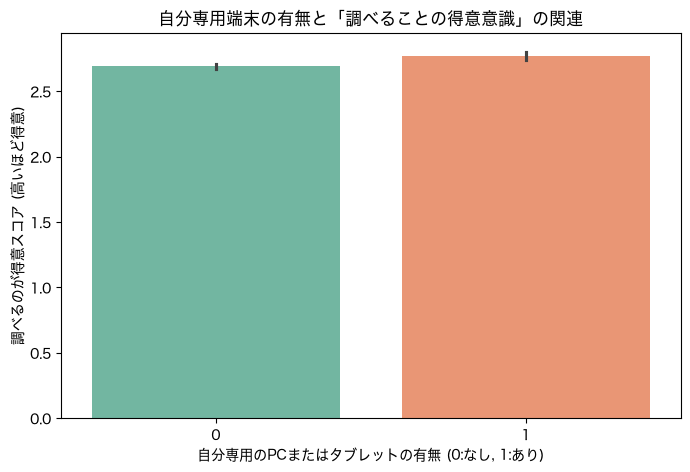

/var/folders/10/j7fx7wx94z9bbj9qk_n4kg6m0000gn/T/ipykernel_17101/28572008.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='w6c_ コロナ禍休校中の学校対応：オンラインで授業があった', y='study_hard_score', data=df_idea2, palette='Set3')


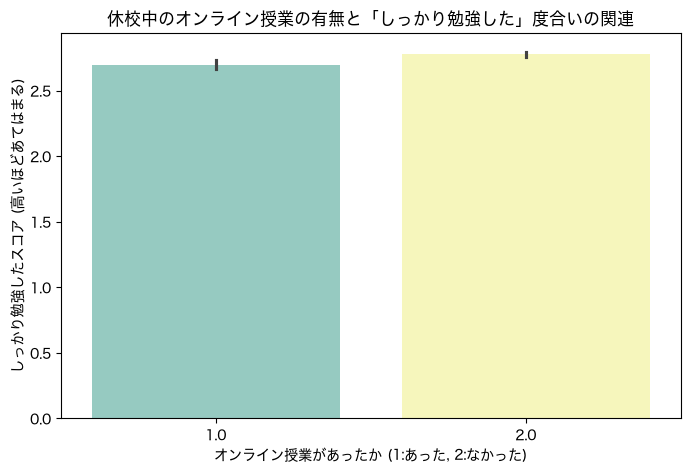

In [8]:
# =========================================================
# アイデア案2：デジタル環境へのアクセス格差と「自分で調べる力」の差
# =========================================================

# 分析に必要な変数の抽出（Wave 6のデータを使用）
# ※列名の `w6c_` の後の半角スペースに注意して指定しています
columns_idea2 = [
    'w6c_ メディア利用：パソコン', 
    'w6c_ メディア利用：タブレット（iPadなど）', 
    'w6c_ 得意・苦手：わからないことや知らないことを調べること', 
    'w6c_ コロナ禍休校中の学校対応：オンラインで授業があった', 
    'w6c_ コロナ禍休校中の家庭生活：しっかり勉強した'
]

df_idea2 = df[columns_idea2].copy()

# 欠損値の処理 (7777, 8888, 9999 をまとめて NaN に置換して除外)
for col in columns_idea2:
    df_idea2[col] = df_idea2[col].replace([7777, 8888, 9999], np.nan)

df_idea2 = df_idea2.dropna()
print("有効データ数:", len(df_idea2))

# 自分専用のPCまたはタブレットがあるかどうかのフラグを作成
# パソコンまたはタブレットが「3(自分専用のものを使っている)」なら1、そうでないなら0
df_idea2['own_device'] = ((df_idea2['w6c_ メディア利用：パソコン'] == 3) | 
                          (df_idea2['w6c_ メディア利用：タブレット（iPadなど）'] == 3)).astype(int)

# 「調べること」の得意スコアの調整（大きいほど得意になるよう反転：5 - 現在の値）
df_idea2['research_skill'] = 5 - df_idea2['w6c_ 得意・苦手：わからないことや知らないことを調べること']

# 休校中に「しっかり勉強した」かのスコア（大きいほどあてはまるよう反転：5 - 現在の値）
df_idea2['study_hard_score'] = 5 - df_idea2['w6c_ コロナ禍休校中の家庭生活：しっかり勉強した']

# ---------------------------------------------------------
# グラフ①：自分専用端末の有無と「調べる力」の関連
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(x='own_device', y='research_skill', data=df_idea2, palette='Set2')
plt.title('自分専用端末の有無と「調べることの得意意識」の関連')
plt.xlabel('自分専用のPCまたはタブレットの有無 (0:なし, 1:あり)')
plt.ylabel('調べるのが得意スコア (高いほど得意)')
plt.show()

# ---------------------------------------------------------
# グラフ②：オンライン授業の有無と休校中の学習状況の関連
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(x='w6c_ コロナ禍休校中の学校対応：オンラインで授業があった', y='study_hard_score', data=df_idea2, palette='Set3')
plt.title('休校中のオンライン授業の有無と「しっかり勉強した」度合いの関連')
plt.xlabel('オンライン授業があったか (1:あった, 2:なかった)')
plt.ylabel('しっかり勉強したスコア (高いほどあてはまる)')
plt.show()

In [10]:
# グラフ①の数値データ（自分専用端末の有無と「調べることの得意意識」平均）
print("■ グラフ①：自分専用端末の有無(0:なし, 1:あり)ごとの「調べることの得意意識」平均")
device_skill_mean = df_idea2.groupby('own_device')['research_skill'].mean().reset_index()
device_skill_mean.columns = ['自分専用端末の有無', '調べるのが得意スコア平均']
display(device_skill_mean)

# グラフ②の数値データ（休校中のオンライン授業の有無と「しっかり勉強した」度合い平均）
# ※列名を修正しています
print("\n■ グラフ②：休校中のオンライン授業の有無(1:あった, 2:なかった)ごとの「しっかり勉強した」度合い平均")
online_study_mean = df_idea2.groupby('w6c_ コロナ禍休校中の学校対応：オンラインで授業があった')['study_hard_score'].mean().reset_index()
online_study_mean.columns = ['オンライン授業の有無', 'しっかり勉強したスコア平均']
display(online_study_mean)

■ グラフ①：自分専用端末の有無(0:なし, 1:あり)ごとの「調べることの得意意識」平均


,自分専用端末の有無,調べるのが得意スコア平均
0,0,2.690397
1,1,2.772566



■ グラフ②：休校中のオンライン授業の有無(1:あった, 2:なかった)ごとの「しっかり勉強した」度合い平均


,オンライン授業の有無,しっかり勉強したスコア平均
0,1.0,2.697647
1,2.0,2.776706


有効データ数: 7475


/var/folders/10/j7fx7wx94z9bbj9qk_n4kg6m0000gn/T/ipykernel_17101/2109331048.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='child_gender_label', y='math_liking_child', data=df_idea3, palette='pastel')


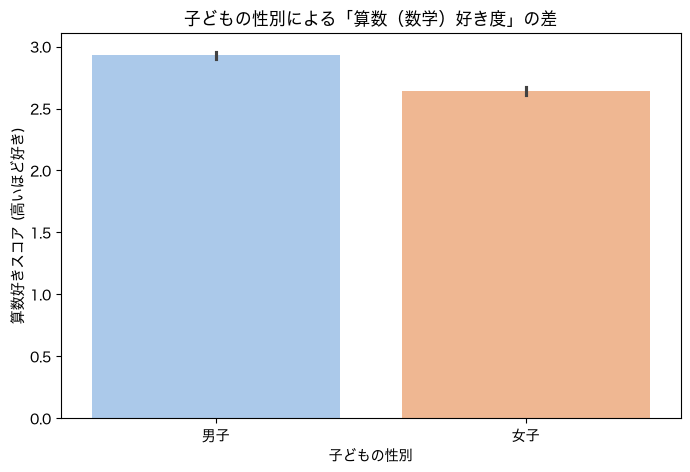

/var/folders/10/j7fx7wx94z9bbj9qk_n4kg6m0000gn/T/ipykernel_17101/2109331048.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bias_level', y='math_liking_child', data=df_idea3_girls, palette='Set1')


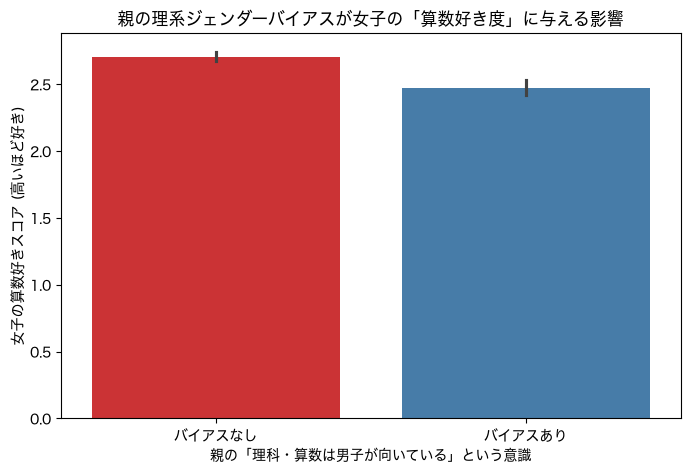

/var/folders/10/j7fx7wx94z9bbj9qk_n4kg6m0000gn/T/ipykernel_17101/2109331048.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bias_level', y='aim_univ', data=df_idea3_girls, palette='Set1')


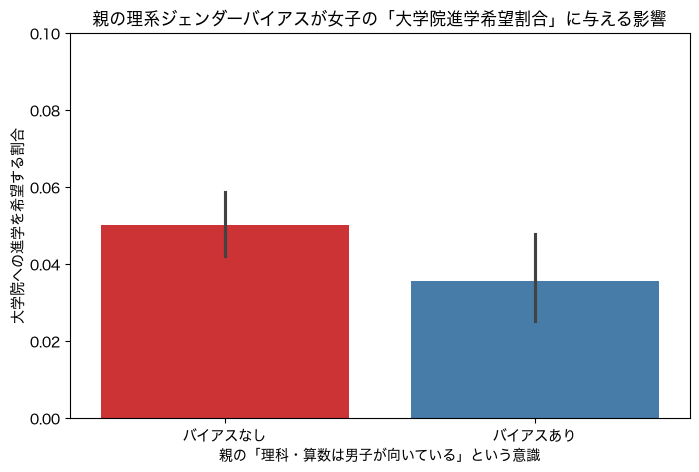

■ グラフ④の数値データ（親のバイアス有無ごとの、女子の算数好き度平均）


,bias_level,math_liking_child
0,バイアスあり,2.474783
1,バイアスなし,2.706789



■ グラフ⑤の数値データ（親のバイアス有無ごとの、女子の大学院進学希望割合）


,bias_level,aim_univ
0,バイアスあり,0.035652
1,バイアスなし,0.050275


In [11]:
# =========================================================
# アイデア案3：「無意識のバイアス」による進路選択の格差（見えない壁）
# =========================================================

# 分析に必要な変数の抽出（Wave 6のデータを使用）
# ※列名の `w6c_ ` や `w6p_ ` の後の半角スペースに注意して指定
columns_idea3 = [
    'w6c_ 子どもの性別', 
    'w6c_ 教科好き：算数（数学）', 
    'w6p_ 意見：算数（数学）や理科は男子のほうが向いている', 
    'w6c_ 将来の希望進学段階'  
]

df_idea3 = df[columns_idea3].copy()

# 欠損値の処理 (7777, 8888, 9999 をまとめて NaN に置換)
for col in columns_idea3:
    df_idea3[col] = df_idea3[col].replace([7777, 8888, 9999], np.nan)

# 教科好きの「5:わからない・ない」、進路の「8:まだ決めていない」「9:わからない」等も分析から除外
df_idea3['w6c_ 教科好き：算数（数学）'] = df_idea3['w6c_ 教科好き：算数（数学）'].replace(5, np.nan)
df_idea3['w6c_ 将来の希望進学段階'] = df_idea3['w6c_ 将来の希望進学段階'].replace([8, 9], np.nan)
df_idea3 = df_idea3.dropna()
print("有効データ数:", len(df_idea3))

# 子どもの算数好きスコア（大きいほど好きになるよう反転：5 - 現在の値）
df_idea3['math_liking_child'] = 5 - df_idea3['w6c_ 教科好き：算数（数学）']

# 親の理系ジェンダーバイアススコア（大きいほど「男子が向いている」と思う：5 - 現在の値）
df_idea3['gender_bias_parent'] = 5 - df_idea3['w6p_ 意見：算数（数学）や理科は男子のほうが向いている']

# 大学院進学希望フラグ (7:大学院まで なら 1、それ以外は 0)
df_idea3['aim_univ'] = df_idea3['w6c_ 将来の希望進学段階'].apply(lambda x: 1 if x == 7 else 0)

# 子どもの性別ラベルを作成
df_idea3['child_gender_label'] = df_idea3['w6c_ 子どもの性別'].map({1.0: '男子', 2.0: '女子'})

# ---------------------------------------------------------
# グラフ③：子どもの性別ごとの「算数好き度」の違い
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(x='child_gender_label', y='math_liking_child', data=df_idea3, palette='pastel')
plt.title('子どもの性別による「算数（数学）好き度」の差')
plt.xlabel('子どもの性別')
plt.ylabel('算数好きスコア (高いほど好き)')
plt.show()

# ---------------------------------------------------------
# グラフ④：親の理系ジェンダーバイアスが強い層と弱い層での、女子の算数好き度の違い
# ---------------------------------------------------------
# 親のバイアススコアが3以上を「バイアスあり」、2以下を「バイアスなし」と定義
df_idea3['bias_level'] = df_idea3['gender_bias_parent'].apply(lambda x: 'バイアスあり' if x >= 3 else 'バイアスなし')
df_idea3_girls = df_idea3[df_idea3['w6c_ 子どもの性別'] == 2.0] # 女子のみ抽出

plt.figure(figsize=(8, 5))
sns.barplot(x='bias_level', y='math_liking_child', data=df_idea3_girls, palette='Set1')
plt.title('親の理系ジェンダーバイアスが女子の「算数好き度」に与える影響')
plt.xlabel('親の「理科・算数は男子が向いている」という意識')
plt.ylabel('女子の算数好きスコア (高いほど好き)')
plt.show()

# ---------------------------------------------------------
# グラフ⑤：親の理系ジェンダーバイアスが女子の「大学院進学希望割合」に与える影響
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(x='bias_level', y='aim_univ', data=df_idea3_girls, palette='Set1')
plt.title('親の理系ジェンダーバイアスが女子の「大学院進学希望割合」に与える影響')
plt.xlabel('親の「理科・算数は男子が向いている」という意識')
plt.ylabel('大学院への進学を希望する割合')
plt.ylim(0, 0.1) # 割合が小さいことが予想されるため上限を10%に設定
plt.show()

# ---------------------------------------------------------
# 数値データの表示
# ---------------------------------------------------------
print("■ グラフ④の数値データ（親のバイアス有無ごとの、女子の算数好き度平均）")
bias_math_mean = df_idea3_girls.groupby('bias_level')['math_liking_child'].mean().reset_index()
display(bias_math_mean)

print("\n■ グラフ⑤の数値データ（親のバイアス有無ごとの、女子の大学院進学希望割合）")
bias_univ_mean = df_idea3_girls.groupby('bias_level')['aim_univ'].mean().reset_index()
display(bias_univ_mean)

In [12]:
print("■ グラフ③：子どもの性別ごとの「算数（数学）好き度」平均")
gender_math_mean = df_idea3.groupby('child_gender_label')['math_liking_child'].mean().reset_index()
gender_math_mean.columns = ['子どもの性別', '算数好きスコア平均']
display(gender_math_mean)

print("■ グラフ④：親の理系ジェンダーバイアスごとの女子の「算数好き度」平均")
bias_math_mean = df_idea3_girls.groupby('bias_level')['math_liking_child'].mean().reset_index()
bias_math_mean.columns = ['親のバイアス', '女子の算数好きスコア平均']
display(bias_math_mean)

print("■ グラフ⑤：親の理系ジェンダーバイアスごとの女子の「大学・大学院進学希望割合」")
bias_univ_mean = df_idea3_girls.groupby('bias_level')['aim_univ'].mean().reset_index()
bias_univ_mean.columns = ['親のバイアス', '女子の大学進学希望割合']
display(bias_univ_mean)

■ グラフ③：子どもの性別ごとの「算数（数学）好き度」平均


,子どもの性別,算数好きスコア平均
0,女子,2.637935
1,男子,2.930556


■ グラフ④：親の理系ジェンダーバイアスごとの女子の「算数好き度」平均


,親のバイアス,女子の算数好きスコア平均
0,バイアスあり,2.474783
1,バイアスなし,2.706789


■ グラフ⑤：親の理系ジェンダーバイアスごとの女子の「大学・大学院進学希望割合」


,親のバイアス,女子の大学進学希望割合
0,バイアスあり,0.035652
1,バイアスなし,0.050275


有効データ数: 11380


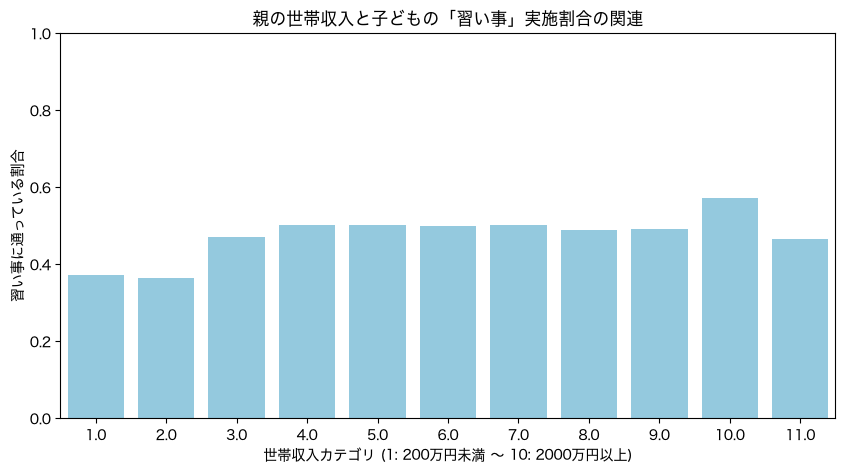

■ 分析①：親の世帯収入カテゴリごとの「習い事」実施割合


,世帯収入(1〜10),習い事実施割合
0,1.0,0.371795
1,2.0,0.364991
2,3.0,0.470149
3,4.0,0.502455
4,5.0,0.500599
5,6.0,0.499406
6,7.0,0.502460
7,8.0,0.488962
8,9.0,0.491228
9,10.0,0.572917


/var/folders/10/j7fx7wx94z9bbj9qk_n4kg6m0000gn/T/ipykernel_17101/277920458.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='lesson_frequency', y='challenge_spirit', data=df_lesson, palette='Set2')


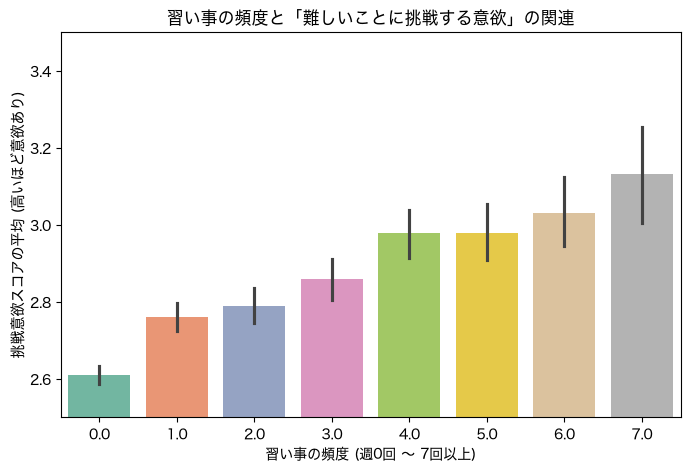

■ 分析②：習い事の頻度(週0〜7回)ごとの「挑戦意欲」平均スコア


,習い事の頻度(回/週),挑戦意欲スコア平均
0,0.0,2.610075
1,1.0,2.760827
2,2.0,2.789366
3,3.0,2.860672
4,4.0,2.978134
5,5.0,2.979123
6,6.0,3.030100
7,7.0,3.132353


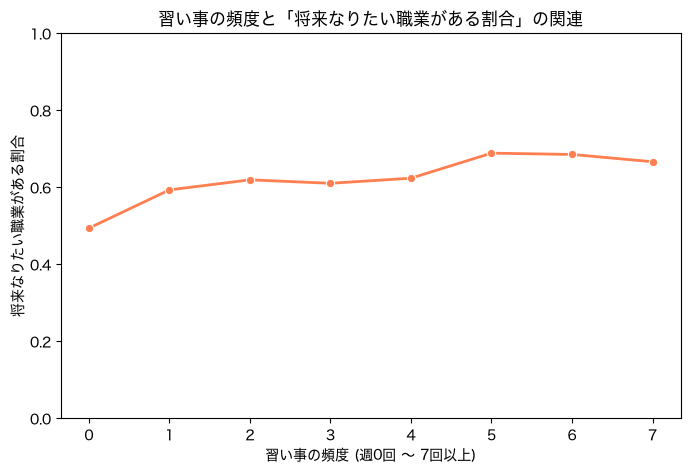

■ 分析③：習い事の頻度(週0〜7回)ごとの「将来なりたい職業がある割合」


,習い事の頻度(回/週),将来の夢がある割合
0,0.0,0.494136
1,1.0,0.593504
2,2.0,0.619632
3,3.0,0.610672
4,4.0,0.623907
5,5.0,0.688935
6,6.0,0.685619
7,7.0,0.666667


In [13]:
# =========================================================
# アイデア案：「習い事」を通じた機会格差とその影響
# =========================================================

# 分析に必要な変数の抽出（Wave 1のデータを使用）
columns_lesson = [
    'w1p_昨年の世帯収入', # 昨年の世帯収入（親）: 1(200万未満)〜10(2000万以上)
    'w1p_習い事やスポーツクラブに通っているか', # 習い事やスポーツクラブに通っているか（親）: 1(行っている), 2(行ってない)
    'w1c_生活時間：（習い事）週に何回行くか', # （習い事）週に何回行くか（子）: 1(1回)〜7(7回以上), 8(行っていない)
    'w1c_性格・特性：難しいことや新しいことにいつも挑戦したい', # 性格・特性：難しいことや新しいことにいつも挑戦したい（子）: 1(とても)〜4(まったく)
    'w1c_将来なりたい職業はあるか'  # 将来なりたい職業はあるか（子）: 1(ある), 2(ない)
]

df_lesson = df[columns_lesson].copy()

# 欠損値の処理 (7777, 8888, 9999 をまとめて NaN に置換して除外)
for col in columns_lesson:
    df_lesson[col] = df_lesson[col].replace([7777, 8888, 9999], np.nan)

df_lesson = df_lesson.dropna()
print("有効データ数:", len(df_lesson))

# ---------------------------------------------------------
# データの加工
# ---------------------------------------------------------
# ①習い事に行っているかどうかのフラグを作成 (1:行っている->1, 2:行っていない->0)
df_lesson['has_lesson'] = df_lesson['w1p_習い事やスポーツクラブに通っているか'].apply(lambda x: 1 if x == 1 else 0)

# ②習い事の回数を数値化 (8:行っていない -> 0回に変換、1〜7はそのまま)
df_lesson['lesson_frequency'] = df_lesson['w1c_生活時間：（習い事）週に何回行くか'].apply(lambda x: 0 if x == 8 else x)

# ③挑戦意欲スコアの調整（値が大きいほど意欲が高いよう反転：5 - 現在の値）
df_lesson['challenge_spirit'] = 5 - df_lesson['w1c_性格・特性：難しいことや新しいことにいつも挑戦したい']

# ④将来の夢のフラグ化 (1:ある->1, 2:ない->0)
df_lesson['has_dream'] = df_lesson['w1c_将来なりたい職業はあるか'].apply(lambda x: 1 if x == 1 else 0)

# ---------------------------------------------------------
# グラフの描画と数値表の表示
# ---------------------------------------------------------
from IPython.display import display

# --- 分析①：世帯収入と「習い事」実施割合の関連 ---
income_lesson = df_lesson.groupby('w1p_昨年の世帯収入')['has_lesson'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='w1p_昨年の世帯収入', y='has_lesson', data=income_lesson, color='skyblue')
plt.title('親の世帯収入と子どもの「習い事」実施割合の関連')
plt.xlabel('世帯収入カテゴリ (1: 200万円未満 ～ 10: 2000万円以上)')
plt.ylabel('習い事に通っている割合')
plt.ylim(0, 1)
plt.show()

print("■ 分析①：親の世帯収入カテゴリごとの「習い事」実施割合")
income_lesson.columns = ['世帯収入(1〜10)', '習い事実施割合']
display(income_lesson)


# --- 分析②：習い事の頻度と「挑戦意欲」の関連 ---
plt.figure(figsize=(8, 5))
# barplotのデフォルト設定で各カテゴリの平均値とエラーバー（信頼区間）が表示されます
sns.barplot(x='lesson_frequency', y='challenge_spirit', data=df_lesson, palette='Set2')
plt.title('習い事の頻度と「難しいことに挑戦する意欲」の関連')
plt.xlabel('習い事の頻度 (週0回 ～ 7回以上)')
plt.ylabel('挑戦意欲スコアの平均 (高いほど意欲あり)')
plt.ylim(2.5, 3.5)
plt.show()

print("■ 分析②：習い事の頻度(週0〜7回)ごとの「挑戦意欲」平均スコア")
freq_challenge_mean = df_lesson.groupby('lesson_frequency')['challenge_spirit'].mean().reset_index()
freq_challenge_mean.columns = ['習い事の頻度(回/週)', '挑戦意欲スコア平均']
display(freq_challenge_mean)


# --- 分析③：習い事の頻度と「将来の夢」の関連 ---
lesson_dream = df_lesson.groupby('lesson_frequency')['has_dream'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(x='lesson_frequency', y='has_dream', data=lesson_dream, marker='o', linewidth=2, color='coral')
plt.title('習い事の頻度と「将来なりたい職業がある割合」の関連')
plt.xlabel('習い事の頻度 (週0回 ～ 7回以上)')
plt.ylabel('将来なりたい職業がある割合')
plt.ylim(0, 1)
plt.show()

print("■ 分析③：習い事の頻度(週0〜7回)ごとの「将来なりたい職業がある割合」")
lesson_dream.columns = ['習い事の頻度(回/週)', '将来の夢がある割合']
display(lesson_dream)

有効データ数: 9900


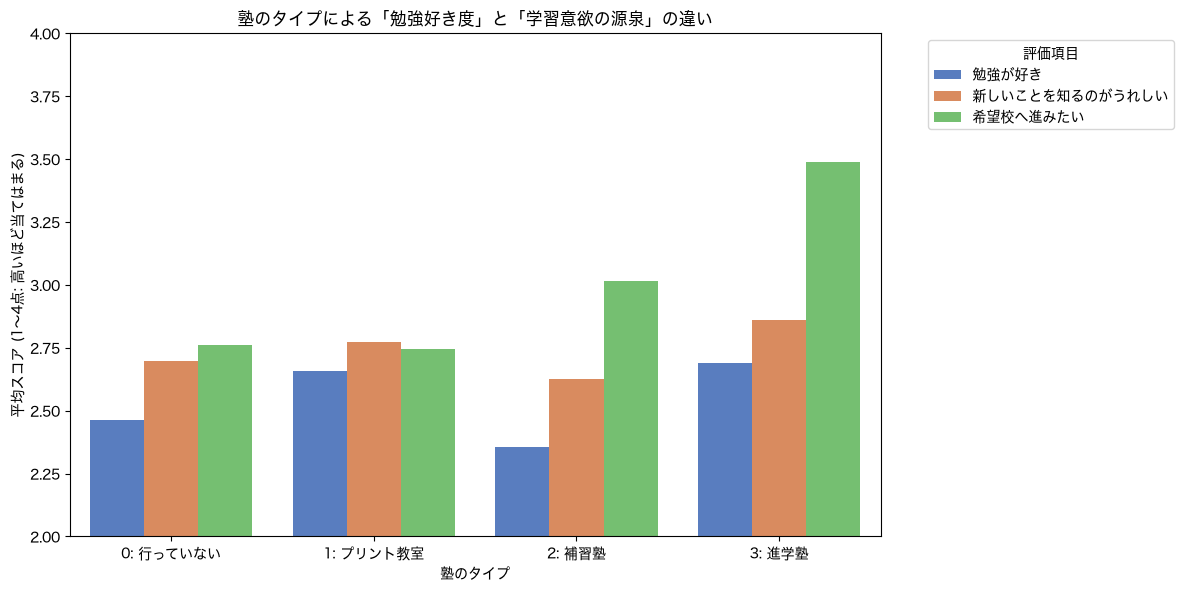

■ 分析結果：塾のタイプごとの平均スコア


,塾のタイプ,勉強好き度,新しいことを知る喜び,希望校への進学意欲
0,0: 行っていない,2.462044,2.697918,2.761308
1,1: プリント教室,2.659396,2.773490,2.746644
2,2: 補習塾,2.354523,2.626732,3.013855
3,3: 進学塾,2.690709,2.859413,3.488998


In [14]:
# =========================================================
# アイデア案：「塾のタイプ」による学習意欲の源泉の違い
# =========================================================

# 分析に必要な変数の抽出（Wave 6のデータを使用）
# ※列名の `w6p_ ` や `w6c_ ` の後の半角スペースに注意して指定
columns_juku = [
    'w6p_ 現在学習塾に行っているか', 
    'w6p_ 学習塾：どのような学習塾に通っているか', 
    'w6c_ 勉強がどれくらい好きか', 
    'w6c_ 学習意欲：新しいことを知るのがうれしいから', 
    'w6c_ 学習意欲：自分の希望する（高校や）大学に進みたいから'  
]

df_juku = df[columns_juku].copy()

# 欠損値の処理 (7777, 8888, 9999 をまとめて NaN に置換)
for col in columns_juku:
    df_juku[col] = df_juku[col].replace([7777, 8888, 9999], np.nan)

# 分析に必要な「子どもの意欲」の回答がないものを除外
df_juku = df_juku.dropna(subset=[
    'w6p_ 現在学習塾に行っているか', 
    'w6c_ 勉強がどれくらい好きか', 
    'w6c_ 学習意欲：新しいことを知るのがうれしいから', 
    'w6c_ 学習意欲：自分の希望する（高校や）大学に進みたいから'
])
print("有効データ数:", len(df_juku))

# ---------------------------------------------------------
# データの加工
# ---------------------------------------------------------
# 塾のタイプを作成する関数
def get_juku_type(row):
    if row['w6p_ 現在学習塾に行っているか'] == 2:
        return '0: 行っていない'
    elif row['w6p_ 現在学習塾に行っているか'] == 1:
        if row['w6p_ 学習塾：どのような学習塾に通っているか'] == 1:
            return '1: プリント教室'
        elif row['w6p_ 学習塾：どのような学習塾に通っているか'] == 2:
            return '2: 補習塾'
        elif row['w6p_ 学習塾：どのような学習塾に通っているか'] == 3:
            return '3: 進学塾'
    return np.nan

# 行単位で関数を適用し、新しい列「juku_type」を作成
df_juku['juku_type'] = df_juku.apply(get_juku_type, axis=1)
df_juku = df_juku.dropna(subset=['juku_type'])

# スコアの反転（数値が大きいほど「好き」「あてはまる」にする：5 - 現在の値）
df_juku['study_like'] = 5 - df_juku['w6c_ 勉強がどれくらい好きか']
df_juku['motivation_curiosity'] = 5 - df_juku['w6c_ 学習意欲：新しいことを知るのがうれしいから']
df_juku['motivation_entrance'] = 5 - df_juku['w6c_ 学習意欲：自分の希望する（高校や）大学に進みたいから']

# ---------------------------------------------------------
# グラフの描画と数値表の表示
# ---------------------------------------------------------
from IPython.display import display

# --- 塾のタイプ別の各スコア平均を算出 ---
juku_grouped = df_juku.groupby('juku_type')[['study_like', 'motivation_curiosity', 'motivation_entrance']].mean().reset_index()

# グラフで描きやすいようにデータ形式を変換（Long形式）
df_melted = pd.melt(juku_grouped, id_vars=['juku_type'], 
                    value_vars=['study_like', 'motivation_curiosity', 'motivation_entrance'],
                    var_name='score_type', value_name='mean_score')

# グラフの凡例用にラベルを変更
label_map = {
    'study_like': '勉強が好き',
    'motivation_curiosity': '新しいことを知るのがうれしい',
    'motivation_entrance': '希望校へ進みたい'
}
df_melted['score_type'] = df_melted['score_type'].map(label_map)

# 棒グラフの描画
plt.figure(figsize=(12, 6))
sns.barplot(x='juku_type', y='mean_score', hue='score_type', data=df_melted, palette='muted')
plt.title('塾のタイプによる「勉強好き度」と「学習意欲の源泉」の違い')
plt.xlabel('塾のタイプ')
plt.ylabel('平均スコア (1〜4点: 高いほど当てはまる)')
plt.legend(title='評価項目', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(2, 4)
plt.tight_layout() # レイアウトの崩れを防ぐ
plt.show()

# 数値表の表示
print("■ 分析結果：塾のタイプごとの平均スコア")
juku_grouped.columns = ['塾のタイプ', '勉強好き度', '新しいことを知る喜び', '希望校への進学意欲']
display(juku_grouped)

In [15]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("=========================================================")
print("塾のタイプ間における各スコアの統計的有意差検定")
print("=========================================================\n")

# 検定対象のスコアとラベル
scores_to_test = {
    'study_like': '勉強が好き',
    'motivation_curiosity': '新しいことを知るのがうれしい',
    'motivation_entrance': '希望する学校に進みたい'
}

for score_col, score_name in scores_to_test.items():
    print(f"■ 【{score_name}】の検定")
    
    # 各塾タイプのデータを抽出
    group0 = df_juku[df_juku['juku_type'] == '0: 行っていない'][score_col]
    group1 = df_juku[df_juku['juku_type'] == '1: プリント教室'][score_col]
    group2 = df_juku[df_juku['juku_type'] == '2: 補習塾'][score_col]
    group3 = df_juku[df_juku['juku_type'] == '3: 進学塾'][score_col]
    
    # 1. 一元配置分散分析 (ANOVA)
    # 4つのグループの平均値に、少なくとも1つ以上の差があるかを検定します
    f_val, p_val = stats.f_oneway(group0, group1, group2, group3)
    
    print(f"  [分散分析] p値 = {p_val:.4e}")
    
    if p_val < 0.05:
        print("  => 全体として、少なくとも1つのグループ間に統計的に有意な差があります。")
        print("  => どのグループ間に差があるか、多重比較検定を行います。\n")
        
        # 2. Tukeyの多重比較検定
        # どの塾タイプとどの塾タイプの間に差があるのかを1対1で総当たりで検定します
        tukey_result = pairwise_tukeyhsd(endog=df_juku[score_col], groups=df_juku['juku_type'], alpha=0.001)
        print(tukey_result)
        
    else:
        print("  => グループ間に統計的な有意差は見られませんでした。")
        
    print("\n" + "-"*60 + "\n")

塾のタイプ間における各スコアの統計的有意差検定

■ 【勉強が好き】の検定
  [分散分析] p値 = 3.3112e-36
  => 全体として、少なくとも1つのグループ間に統計的に有意な差があります。
  => どのグループ間に差があるか、多重比較検定を行います。

   Multiple Comparison of Means - Tukey HSD, FWER=0.00    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
0: 行っていない 1: プリント教室   0.1974    0.0  0.0679  0.3268   True
0: 行っていない    2: 補習塾  -0.1075 0.0001 -0.2017 -0.0133   True
0: 行っていない    3: 進学塾   0.2287    0.0  0.1449  0.3124   True
1: プリント教室    2: 補習塾  -0.3049    0.0 -0.4558  -0.154   True
1: プリント教室    3: 進学塾   0.0313 0.8483 -0.1133  0.1759  False
   2: 補習塾    3: 進学塾   0.3362    0.0   0.222  0.4503   True
----------------------------------------------------------

------------------------------------------------------------

■ 【新しいことを知るのがうれしい】の検定
  [分散分析] p値 = 9.6539e-14
  => 全体として、少なくとも1つのグループ間に統計的に有意な差があります。
  => どのグループ間に差があるか、多重比較検定を行います。

   Multiple Comparison of Means - Tukey HSD, FWER=0.00   
  group1    group2  meandiff p-ad